In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import joblib
import json
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
#RANDOM FOREST
# Load data
data = pd.read_csv("synthetic_water_quality_3months.csv")

# Features and labels
X = data[["temperature", "ph", "turbidity", "tds"]]
y = data["dump_detected"]

# Split dataset (80-20 random split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"✅ Random Forest | Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")

# Save model and metrics
joblib.dump(model, "random_forest_model.pkl")
metrics = {"train_acc": train_acc, "test_acc": test_acc}
json.dump(metrics, open("rf_metrics.json", "w"))


✅ Random Forest | Train Accuracy: 1.0000, Test Accuracy: 0.9986


In [ ]:
#XGBOOST
# Load data
data = pd.read_csv("synthetic_water_quality_3months.csv")

X = data[["temperature", "ph", "turbidity", "tds"]]
y = data["dump_detected"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Train model
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"✅ XGBoost | Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")

# Save model and metrics
joblib.dump(model, "xgboost_model.pkl")
metrics = {"train_acc": train_acc, "test_acc": test_acc}
json.dump(metrics, open("xgb_metrics.json", "w"))


✅ XGBoost | Train Accuracy: 0.9987, Test Accuracy: 0.9975


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:34:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:

#LOGISTIC REGRESSION
# Load data
data = pd.read_csv("synthetic_water_quality_3months.csv")

X = data[["temperature", "ph", "turbidity", "tds"]]
y = data["dump_detected"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"✅ Logistic Regression | Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")

# Save model and metrics
joblib.dump(model, "logistic_regression_model.pkl")
metrics = {"train_acc": train_acc, "test_acc": test_acc}
json.dump(metrics, open("lr_metrics.json", "w"))


✅ Logistic Regression | Train Accuracy: 0.8806, Test Accuracy: 0.8827


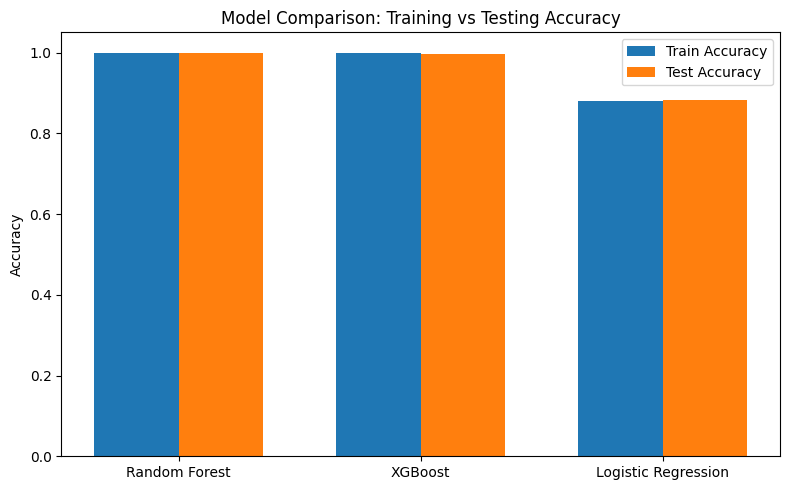

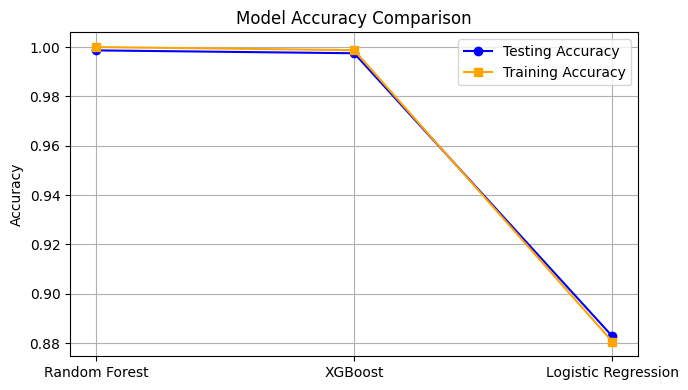

📈 Comparison complete. Best model: Random Forest with accuracy: 0.9986496913580247


In [ ]:
#Plotting
# Load metrics
rf = json.load(open("rf_metrics.json"))
xgb = json.load(open("xgb_metrics.json"))
lr = json.load(open("lr_metrics.json"))

models = ["Random Forest", "XGBoost", "Logistic Regression"]
train_acc = [rf["train_acc"], xgb["train_acc"], lr["train_acc"]]
test_acc = [rf["test_acc"], xgb["test_acc"], lr["test_acc"]]

# Plot 1: Train vs Test accuracy per model
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, train_acc, width, label='Train Accuracy')
plt.bar(x + width/2, test_acc, width, label='Test Accuracy')

plt.ylabel('Accuracy')
plt.title('Model Comparison: Training vs Testing Accuracy')
plt.xticks(x, models)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Overall comparison
plt.figure(figsize=(7,4))
plt.plot(models, test_acc, marker='o', label="Testing Accuracy", color='blue')
plt.plot(models, train_acc, marker='s', label="Training Accuracy", color='orange')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("📈 Comparison complete. Best model:", models[np.argmax(test_acc)], "with accuracy:", max(test_acc))


Training samples: (20726, 12, 4), Testing samples: (5182, 12, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9227 - loss: 0.2265 - val_accuracy: 0.9774 - val_loss: 0.0956
Epoch 2/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9819 - loss: 0.0845 - val_accuracy: 0.9799 - val_loss: 0.0858
Epoch 3/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9813 - loss: 0.0875 - val_accuracy: 0.9801 - val_loss: 0.0870
Epoch 4/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9848 - loss: 0.0743 - val_accuracy: 0.9838 - val_loss: 0.0803
Epoch 5/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9858 - loss: 0.0702 - val_accuracy: 0.9846 - val_loss: 0.0764
Epoch 6/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9857 - loss: 0.0722 - val_accuracy: 0.9849 - val_loss: 0.0749
Epoch 7/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9879 - loss: 0.0625 - val_accuracy: 0.9849 - val_loss: 0.0760
Epoch 8/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9877 - loss: 0.0640 - val_accuracy: 0


✅ CNN Test Accuracy: 0.9871
💾 Model saved as cnn_model.h5


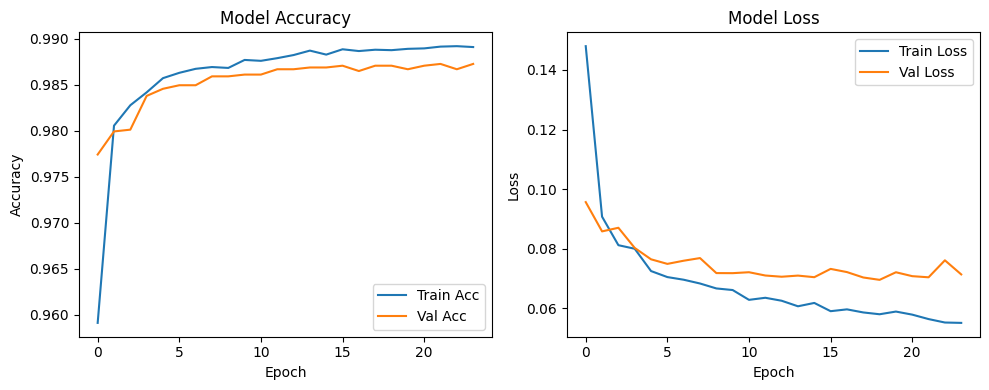

In [ ]:
#CNN
# === Load data ===
data = pd.read_csv("synthetic_water_quality_3months.csv")

features = ["temperature", "ph", "turbidity", "tds"]
X = data[features].values
y = data["dump_detected"].values

# === Normalize features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Create time windows ===
def create_sequences(X, y, window_size=12):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i+window_size])
        ys.append(y[i+window_size])
    return np.array(Xs), np.array(ys)

window_size = 12  # last 12 readings (1 hour at 5-min interval)
X_seq, y_seq = create_sequences(X_scaled, y, window_size)

# === Split data (80/20 randomized) ===
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, shuffle=True)

print(f"Training samples: {X_train.shape}, Testing samples: {X_test.shape}")

# === CNN Model ===
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(window_size, len(features))),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# === Train model ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# === Evaluate ===
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n✅ CNN Test Accuracy: {test_acc:.4f}")

# === Save model ===
model.save("cnn_model.h5")
print("💾 Model saved as cnn_model.h5")

# === Plot accuracy & loss ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import os, json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle as sk_shuffle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import joblib

# --------------------------------------------
# Configuration
# --------------------------------------------
DATA_PATH = "synthetic_water_quality_3months.csv"
OUT_DIR = "data"
MODEL_PATH = os.path.join(OUT_DIR, "cnn_model.h5")
HISTORY_PATH = os.path.join(OUT_DIR, "cnn_training_history.json")
SUMMARY_PATH = os.path.join(OUT_DIR, "cnn_model_summary.json")
SCALER_PATH = os.path.join(OUT_DIR, "feature_scaler.joblib")

os.makedirs(OUT_DIR, exist_ok=True)

# --------------------------------------------
# Load dataset
# --------------------------------------------
data = pd.read_csv(DATA_PATH)

# Feature columns with case-insensitive fallback for "ph"
possible_ph_cols = [c for c in data.columns if c.lower() == "ph"]
if not possible_ph_cols:
    raise ValueError("No pH column found (expected 'ph' in any case).")
ph_col = possible_ph_cols[0]

feature_cols = ["temperature", ph_col, "turbidity", "tds"]
target_col = "dump_detected"

# Validate columns
missing = [c for c in feature_cols + [target_col] if c not in data.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

X = data[feature_cols].values.astype(np.float32)
y = data[target_col].values.astype(np.int32)

# --------------------------------------------
# Create sliding windows (timesteps)
# --------------------------------------------
def create_sequences(X_arr, y_arr, window_size=12):
    Xs, ys = [], []
    for i in range(len(X_arr) - window_size):
        Xs.append(X_arr[i:i+window_size])       # shape: (window, features)
        ys.append(y_arr[i+window_size])         # predict next step label
    return np.asarray(Xs), np.asarray(ys)

window_size = 12  # e.g., last 12 readings
# Scale BEFORE windowing or AFTER? Do after fitting on full X for stationarity.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, SCALER_PATH)

X_seq, y_seq = create_sequences(X_scaled, y, window_size)  # -> (samples, timesteps, features)

# --------------------------------------------
# Train / test split
# --------------------------------------------
# Shuffle first to reduce temporal bias, then stratify split if both classes present
X_seq, y_seq = sk_shuffle(X_seq, y_seq, random_state=42)

if len(np.unique(y_seq)) > 1:
    stratify = y_seq
else:
    stratify = None

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=stratify
)

# --------------------------------------------
# Build CNN model (Conv1D needs (timesteps, features))
# --------------------------------------------
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(timesteps, n_features)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# --------------------------------------------
# Train model with early stopping
# --------------------------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# --------------------------------------------
# Evaluate
# --------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ CNN Test Accuracy: {test_acc:.4f}")

# --------------------------------------------
# Save model and history
# --------------------------------------------
model.save(MODEL_PATH)
print(f"✅ Model saved to {MODEL_PATH}")

history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open(HISTORY_PATH, "w") as f:
    json.dump(history_dict, f, indent=2)
print(f"✅ Training history saved to {HISTORY_PATH}")

# --------------------------------------------
# Save model summary as structured JSON (robust)
# --------------------------------------------
layers_json = []
for layer in model.layers:
    cfg = layer.get_config()
    entry = {
        "name": layer.name,
        "class_name": layer.__class__.__name__,
        "output_shape": str(getattr(layer, "output_shape", None)),
        "params": int(layer.count_params()),
        "config": cfg
    }
    layers_json.append(entry)

summary_obj = {
    "layers": layers_json,
    "total_params": int(model.count_params()),
    "trainable_params": int(np.sum([np.prod(w.shape) for w in model.trainable_weights])),
    "non_trainable_params": int(np.sum([np.prod(w.shape) for w in model.non_trainable_weights]))
}

with open(SUMMARY_PATH, "w") as f:
    json.dump(summary_obj, f, indent=2)

print(f"✅ Model summary saved to {SUMMARY_PATH}")
print(f"✅ Scaler saved to {SCALER_PATH}")


Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


324/324 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9258 - loss: 0.2296 - val_accuracy: 0.9780 - val_loss: 0.1012
Epoch 2/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9788 - loss: 0.0988 - val_accuracy: 0.9813 - val_loss: 0.0786
Epoch 3/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9822 - loss: 0.0857 - val_accuracy: 0.9836 - val_loss: 0.0792
Epoch 4/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9827 - loss: 0.0806 - val_accuracy: 0.9848 - val_loss: 0.0750
Epoch 5/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9849 - loss: 0.0758 - val_accuracy: 0.9849 - val_loss: 0.0692
Epoch 6/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9844 - loss: 0.0750 - val_accuracy: 0.9855 - val_loss: 0.0693
Epoch 7/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9857 - loss: 0.0741 - val_accuracy: 0.9863 - val_loss: 0.0688
Epoch 8/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9866 - loss: 0.0692 - val_accuracy: 0.9865 - val

✅ CNN Test Accuracy: 0.9875
✅ Model saved to data/cnn_model.h5
✅ Training history saved to data/cnn_training_history.json
✅ Model summary saved to data/cnn_model_summary.json
✅ Scaler saved to data/feature_scaler.joblib


In [ ]:
pip install flask flask-cors pyngrok

In [ ]:
# Add this at the TOP of the Colab notebook
from flask import Flask, jsonify, request
from flask_cors import CORS
import pandas as pd

app = Flask(_name_)
CORS(app)  # IMPORTANT: Allows your frontend to connect

# Example API endpoint - your friend should modify based on their data
@app.route('/api/sensors', methods=['GET'])
def get_sensors():
    # This should return real sensor data from IoT or database
    sensors = [
        {
            'id': 1,
            'name': 'Node 01',
            'lat': 19.0760,
            'lon': 72.8777,
            'tds': 320,
            'ph': 7.2,
            'do': 8.5,
            'turbidity': 5,
            'status': 'normal'
        },
        # ... more sensors
    ]
    return jsonify(sensors)

# Add more endpoints as needed
@app.route('/api/predictions', methods=['GET'])
def get_predictions():
    # Return ML model predictions
    predictions = {
        'next_24h': [320, 330, 340, 450, 520, 480, 400],
        'confidence': 87.3
    }
    return jsonify(predictions)

# CRITICAL: Use ngrok to expose the server
from pyngrok import ngrok

# Start ngrok tunnel
public_url = ngrok.connect(5000)
print(' PUBLIC URL:', public_url)
print(' Copy this URL and give it to your frontend teammate!')

# Run Flask app
app.run(port=5000)

NameError: name '_name_' is not defined